# Teaching GROUP BY with DuckDB

This notebook answers the requested GROUP BY questions using the small `sales.csv` dataset.

For each question, the notebook includes:
1. Natural-language question
2. SQL query
3. Explanation of the SQL
4. Business insight
5. A simple plot when it helps

## Setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:,.0f}'.format)

con = duckdb.connect()

INPUT_PATH = "."
file_path = f"{INPUT_PATH}/sales.csv"

con.execute("""
CREATE OR REPLACE TABLE sales AS
SELECT * FROM read_csv_auto(?);
""", [file_path])

con.execute("SELECT * FROM sales LIMIT 5").df()

,country,product,price
0,FRANCE,TV,200
1,FRANCE,TV,400
2,FRANCE,BIKE,400
3,FRANCE,BIKE,600
4,USA,TV,200


## Schema and Row Count

In [2]:
schema_df = con.execute("DESCRIBE sales").df()
row_df = con.execute("SELECT COUNT(*) AS row_count FROM sales").df()
schema_df, row_df

(  column_name column_type null   key default extra
 0     country     VARCHAR  YES  None    None  None
 1     product     VARCHAR  YES  None    None  None
 2       price      BIGINT  YES  None    None  None,
    row_count
 0         16)

## 1. Display all records from sales table

**Question:** Display all records from sales table.

### SQL

In [3]:
sql = """SELECT *
FROM sales;"""
print(sql)

SELECT *
FROM sales;


### Run SQL

In [4]:
df = con.execute(sql).df()
df

,country,product,price
0,FRANCE,TV,200
1,FRANCE,TV,400
2,FRANCE,BIKE,400
3,FRANCE,BIKE,600
4,USA,TV,200
5,USA,TV,180
6,USA,TV,240
7,USA,BIKE,500
8,USA,BIKE,700
9,USA,COMPUTER,800


### SQL Explanation
This query reads every row and every column from the `sales` table.  
It is the simplest way to inspect the raw data before doing aggregation.

### Business Insight
Before using `GROUP BY`, it is important to understand the raw transaction-level data.  
This helps confirm the columns available for later grouping: `country`, `product`, and `price`.

## 2. Total sales for all products for USA

**Question:** Find total sales for all products for USA.

### SQL

In [5]:
sql = """SELECT 
    country,
    SUM(price) AS total_sales
FROM sales
WHERE country = 'USA'
GROUP BY country;"""
print(sql)

SELECT 
    country,
    SUM(price) AS total_sales
FROM sales
WHERE country = 'USA'
GROUP BY country;


### Run SQL

In [6]:
df = con.execute(sql).df()
df

,country,total_sales
0,USA,"3,920"


### SQL Explanation
`WHERE country = 'USA'` filters rows to USA only.  
`SUM(price)` adds the prices of all USA sales.  
`GROUP BY country` returns one aggregated row for USA.

### Business Insight
This gives the overall revenue generated in the USA.  
It is useful for country-level performance measurement and for comparing with other markets later.

### Plot

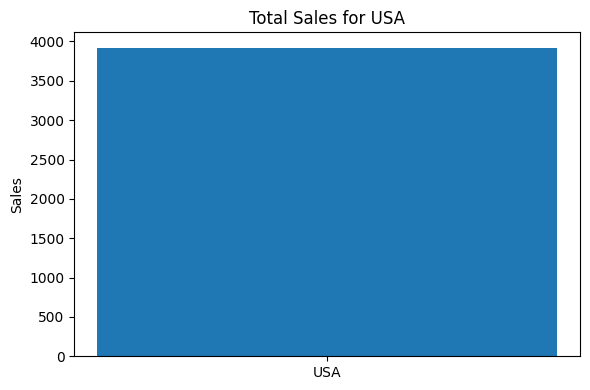

In [7]:
plt.figure(figsize=(6,4))
plt.bar(df['country'], df['total_sales'])
plt.title('Total Sales for USA')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

## 3. Total sales for all products for all countries

**Question:** Find total sales for all products for all countries.

### SQL

In [8]:
sql = """SELECT 
    country,
    SUM(price) AS total_sales
FROM sales
GROUP BY country
ORDER BY total_sales DESC;"""
print(sql)

SELECT 
    country,
    SUM(price) AS total_sales
FROM sales
GROUP BY country
ORDER BY total_sales DESC;


### Run SQL

In [9]:
df = con.execute(sql).df()
df

,country,total_sales
0,USA,"3,920"
1,CANADA,"1,900"
2,FRANCE,"1,600"


### SQL Explanation
The query groups all rows by `country` and computes total sales with `SUM(price)`.  
`ORDER BY total_sales DESC` sorts countries from highest to lowest total sales.

### Business Insight
This compares country performance directly.  
Management can quickly see which country is strongest and which country may need improvement.

### Plot

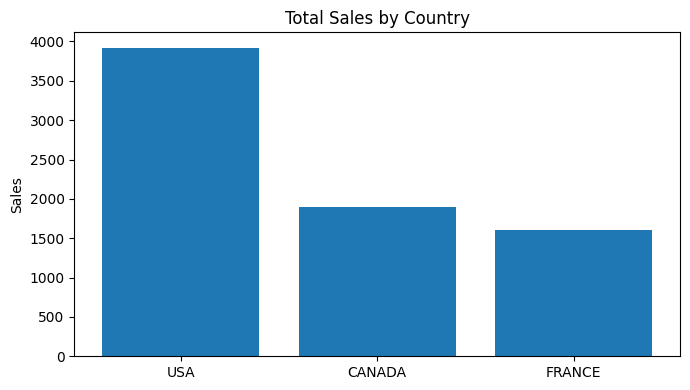

In [10]:
plt.figure(figsize=(7,4))
plt.bar(df['country'], df['total_sales'])
plt.title('Total Sales by Country')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

## 4. List of unique countries

**Question:** Find the list of unique countries.

### SQL

In [11]:
sql = """SELECT DISTINCT country
FROM sales
ORDER BY country;"""
print(sql)

SELECT DISTINCT country
FROM sales
ORDER BY country;


### Run SQL

In [12]:
df = con.execute(sql).df()
df

,country
0,CANADA
1,FRANCE
2,USA


### SQL Explanation
`DISTINCT` removes duplicates and returns each country only once.  
This is not a `GROUP BY` query, but it is often used before aggregation to understand dimensions.

### Business Insight
This tells us which markets exist in the dataset.  
It is useful when validating the data before performing grouped analysis.

## 5. List of unique products

**Question:** Find the list of unique products.

### SQL

In [13]:
sql = """SELECT DISTINCT product
FROM sales
ORDER BY product;"""
print(sql)

SELECT DISTINCT product
FROM sales
ORDER BY product;


### Run SQL

In [14]:
df = con.execute(sql).df()
df

,product
0,BIKE
1,COMPUTER
2,TV


### SQL Explanation
`DISTINCT product` returns the unique product categories sold in the table.

### Business Insight
This shows the product catalog represented in the data.  
It helps define the business dimensions that can be grouped later.

## 6. Total product sales per country

**Question:** Find total product sales per country.

### SQL

In [15]:
sql = """SELECT 
    country,
    SUM(price) AS total_sales
FROM sales
GROUP BY country
ORDER BY total_sales DESC;"""
print(sql)

SELECT 
    country,
    SUM(price) AS total_sales
FROM sales
GROUP BY country
ORDER BY total_sales DESC;


### Run SQL

In [16]:
df = con.execute(sql).df()
df

,country,total_sales
0,USA,"3,920"
1,CANADA,"1,900"
2,FRANCE,"1,600"


### SQL Explanation
This is the classic first `GROUP BY` pattern: aggregate one metric by one dimension.  
Here, the metric is `SUM(price)` and the dimension is `country`.

### Business Insight
The result shows how much each country contributes to total sales.  
It can guide market prioritization and country-specific strategy.

### Plot

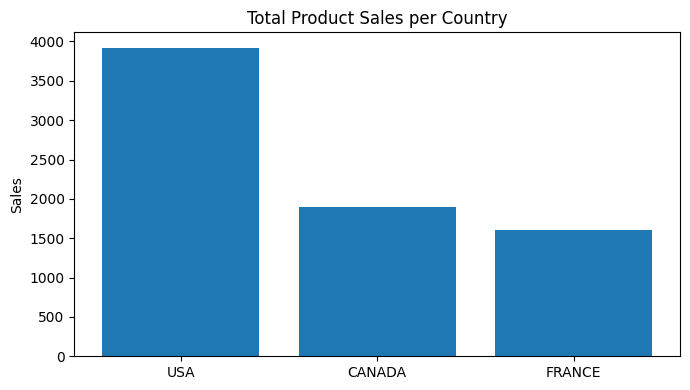

In [17]:
plt.figure(figsize=(7,4))
plt.bar(df['country'], df['total_sales'])
plt.title('Total Product Sales per Country')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

## 7. Total product sales per product

**Question:** Find total product sales per product.

### SQL

In [18]:
sql = """SELECT 
    product,
    SUM(price) AS total_sales
FROM sales
GROUP BY product
ORDER BY total_sales DESC;"""
print(sql)

SELECT 
    product,
    SUM(price) AS total_sales
FROM sales
GROUP BY product
ORDER BY total_sales DESC;


### Run SQL

In [19]:
df = con.execute(sql).df()
df

,product,total_sales
0,COMPUTER,"3,500"
1,BIKE,"2,200"
2,TV,"1,720"


### SQL Explanation
This groups the rows by product instead of country.  
Each product receives one aggregated total using `SUM(price)`.

### Business Insight
This reveals which product line drives the most revenue.  
It helps with product strategy, promotions, and inventory decisions.

### Plot

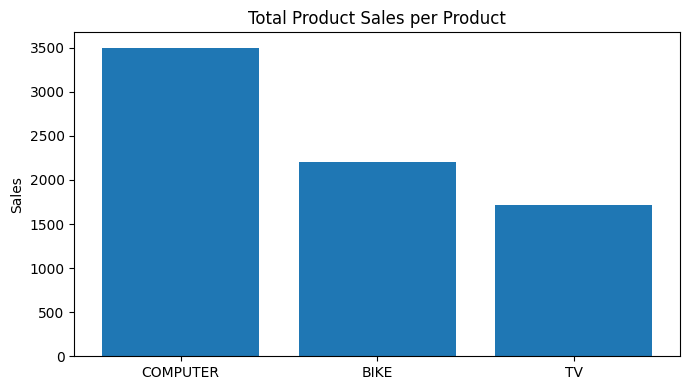

In [20]:
plt.figure(figsize=(7,4))
plt.bar(df['product'], df['total_sales'])
plt.title('Total Product Sales per Product')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

## 8. Total product sales per country and product

**Question:** Find total product sales per country and product.

### SQL

In [21]:
sql = """SELECT 
    country,
    product,
    SUM(price) AS total_sales
FROM sales
GROUP BY country, product
ORDER BY country, total_sales DESC;"""
print(sql)

SELECT 
    country,
    product,
    SUM(price) AS total_sales
FROM sales
GROUP BY country, product
ORDER BY country, total_sales DESC;


### Run SQL

In [22]:
df = con.execute(sql).df()
df

,country,product,total_sales
0,CANADA,COMPUTER,"1,400"
1,CANADA,TV,500
2,FRANCE,BIKE,"1,000"
3,FRANCE,TV,600
4,USA,COMPUTER,"2,100"
5,USA,BIKE,"1,200"
6,USA,TV,620


### SQL Explanation
This query uses a multi-column `GROUP BY`.  
It creates one group for each `(country, product)` combination and computes total sales for each pair.

### Business Insight
This provides a more detailed view than grouping by country or product alone.  
It helps answer questions such as: which product is strongest inside each country?

## 9. Number of sales per country

**Question:** Find the number of sales per country.

### SQL

In [23]:
sql = """SELECT 
    country,
    COUNT(*) AS num_sales
FROM sales
GROUP BY country
ORDER BY num_sales DESC;"""
print(sql)

SELECT 
    country,
    COUNT(*) AS num_sales
FROM sales
GROUP BY country
ORDER BY num_sales DESC;


### Run SQL

In [24]:
df = con.execute(sql).df()
df

,country,num_sales
0,USA,8
1,FRANCE,4
2,CANADA,4


### SQL Explanation
`COUNT(*)` counts the number of rows in each country group.  
This measures transaction volume rather than revenue.

### Business Insight
A country may have many transactions but not the highest revenue.  
This distinction is important: volume and value are not always the same.

### Plot

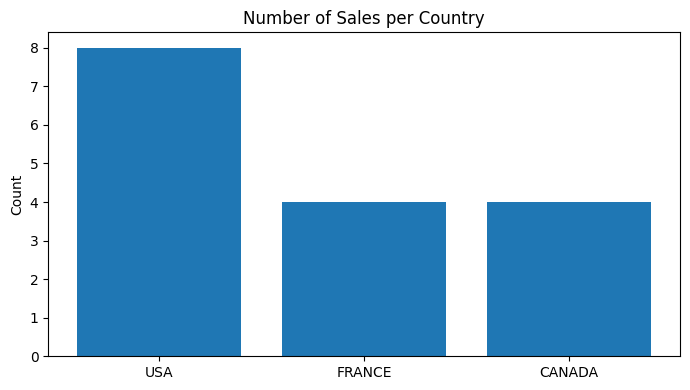

In [25]:
plt.figure(figsize=(7,4))
plt.bar(df['country'], df['num_sales'])
plt.title('Number of Sales per Country')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 10. Top selling product per country

**Question:** Write a SQL query to find top selling product per country.

### SQL

In [26]:
sql = """SELECT *
FROM (
    SELECT 
        country,
        product,
        SUM(price) AS total_sales,
        RANK() OVER (
            PARTITION BY country
            ORDER BY SUM(price) DESC
        ) AS rnk
    FROM sales
    GROUP BY country, product
) t
WHERE rnk = 1
ORDER BY country;"""
print(sql)

SELECT *
FROM (
    SELECT 
        country,
        product,
        SUM(price) AS total_sales,
        RANK() OVER (
            PARTITION BY country
            ORDER BY SUM(price) DESC
        ) AS rnk
    FROM sales
    GROUP BY country, product
) t
WHERE rnk = 1
ORDER BY country;


### Run SQL

In [27]:
df = con.execute(sql).df()
df

,country,product,total_sales,rnk
0,CANADA,COMPUTER,"1,400",1
1,FRANCE,BIKE,"1,000",1
2,USA,COMPUTER,"2,100",1


### SQL Explanation
First, `GROUP BY country, product` computes sales totals per product within each country.  
Then `RANK() OVER (PARTITION BY country ORDER BY SUM(price) DESC)` ranks products inside each country.  
Finally, `WHERE rnk = 1` keeps the top product per country.

### Business Insight
This shows the best-performing product in each market.  
It is useful for local marketing strategy and identifying country-specific preferences.

### Plot

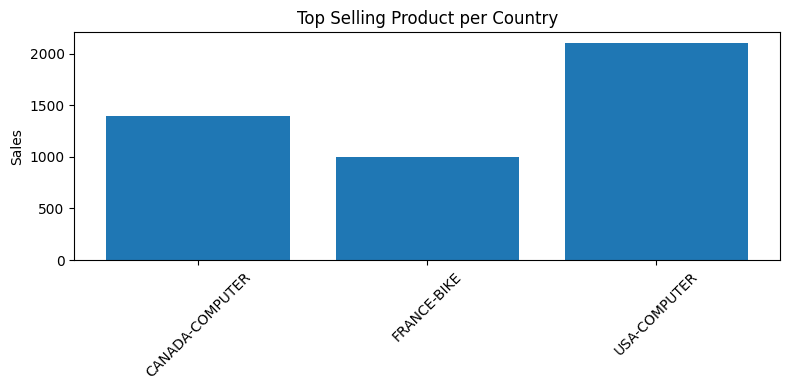

In [28]:
plt.figure(figsize=(8,4))
labels = df['country'] + '-' + df['product']
plt.bar(labels, df['total_sales'])
plt.title('Top Selling Product per Country')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Top selling country overall

**Question:** Write a SQL query to find top selling country overall.

### SQL

In [29]:
sql = """SELECT 
    country,
    SUM(price) AS total_sales
FROM sales
GROUP BY country
ORDER BY total_sales DESC
LIMIT 1;"""
print(sql)

SELECT 
    country,
    SUM(price) AS total_sales
FROM sales
GROUP BY country
ORDER BY total_sales DESC
LIMIT 1;


### Run SQL

In [30]:
df = con.execute(sql).df()
df

,country,total_sales
0,USA,"3,920"


### SQL Explanation
This groups by country, computes total sales, sorts from highest to lowest, and returns the top row only.

### Business Insight
This identifies the best-performing market overall.  
It is a simple but important executive-level KPI.

## 12. Full ranking of all countries

**Question:** Show full ranking of all countries based on sale of products.

### SQL

In [31]:
sql = """SELECT 
    country,
    SUM(price) AS total_sales,
    RANK() OVER (ORDER BY SUM(price) DESC) AS country_rank
FROM sales
GROUP BY country
ORDER BY country_rank;"""
print(sql)

SELECT 
    country,
    SUM(price) AS total_sales,
    RANK() OVER (ORDER BY SUM(price) DESC) AS country_rank
FROM sales
GROUP BY country
ORDER BY country_rank;


### Run SQL

In [32]:
df = con.execute(sql).df()
df

,country,total_sales,country_rank
0,USA,"3,920",1
1,CANADA,"1,900",2
2,FRANCE,"1,600",3


### SQL Explanation
`GROUP BY country` computes country totals, and the window function `RANK()` assigns a ranking based on descending total sales.

### Business Insight
This gives a complete leaderboard of markets.  
It is more informative than only showing the top country because it shows the relative position of every country.

### Plot

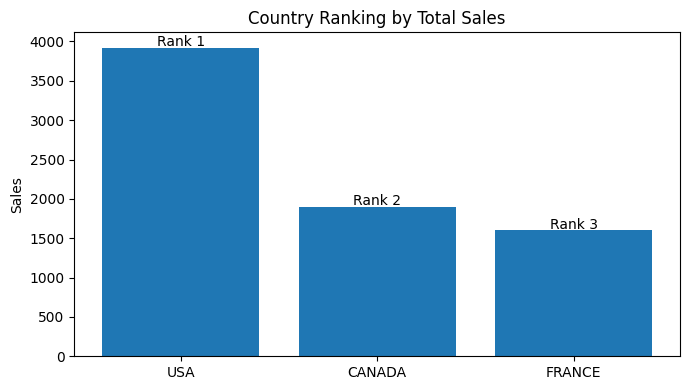

In [33]:
plt.figure(figsize=(7,4))
plt.bar(df['country'], df['total_sales'])
for i, v in enumerate(df['country_rank']):
    plt.text(i, df['total_sales'].iloc[i] + 20, f'Rank {int(v)}', ha='center')
plt.title('Country Ranking by Total Sales')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

## 13. Countries with more than $1500 in sales

**Question:** Find list of countries which have sold products more than $1500.

### SQL

In [36]:
sql = """SELECT 
    country,
    SUM(price) AS total_sales
FROM sales
GROUP BY country
HAVING SUM(price) > 1800
ORDER BY total_sales DESC;"""
print(sql)

SELECT 
    country,
    SUM(price) AS total_sales
FROM sales
GROUP BY country
HAVING SUM(price) > 1800
ORDER BY total_sales DESC;


### Run SQL

In [37]:
df = con.execute(sql).df()
df

,country,total_sales
0,USA,"3,920"
1,CANADA,"1,900"


### SQL Explanation
`HAVING` filters groups after aggregation.  
This is different from `WHERE`, which filters rows before aggregation.  
Here, only countries with grouped total sales above 1500 are returned.

### Business Insight
This identifies strong markets that pass a business threshold.  
Threshold-based grouping is common in reporting and decision-making.

## 14. Highest price product sold per country

**Question:** Find highest price product sold per country.

### SQL

In [38]:
sql = """SELECT 
    country,
    MAX(price) AS highest_price
FROM sales
GROUP BY country
ORDER BY highest_price DESC;"""
print(sql)

SELECT 
    country,
    MAX(price) AS highest_price
FROM sales
GROUP BY country
ORDER BY highest_price DESC;


### Run SQL

In [39]:
df = con.execute(sql).df()
df

,country,highest_price
0,CANADA,900
1,USA,800
2,FRANCE,600


### SQL Explanation
`MAX(price)` returns the highest individual transaction value inside each country group.

### Business Insight
This highlights the most expensive sale observed in each market.  
It helps identify where premium products or high-value purchases occur.

### Plot

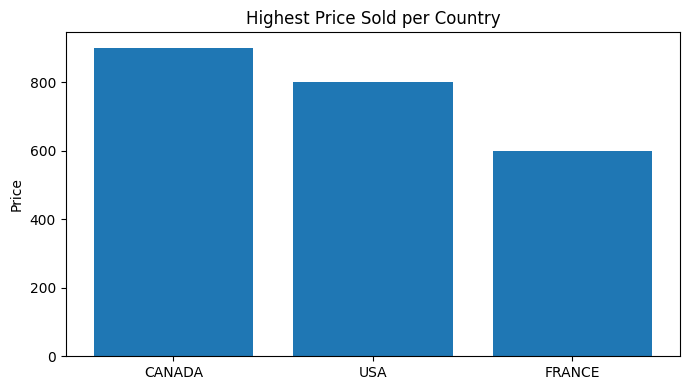

In [40]:
plt.figure(figsize=(7,4))
plt.bar(df['country'], df['highest_price'])
plt.title('Highest Price Sold per Country')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# Extra GROUP BY Practice

## E1. Average selling price per country

**Question:** Find average selling price per country.

### SQL

In [41]:
sql = """SELECT 
    country,
    AVG(price) AS avg_price
FROM sales
GROUP BY country
ORDER BY avg_price DESC;"""
print(sql)

SELECT 
    country,
    AVG(price) AS avg_price
FROM sales
GROUP BY country
ORDER BY avg_price DESC;


### Run SQL

In [42]:
df = con.execute(sql).df()
df

,country,avg_price
0,USA,490
1,CANADA,475
2,FRANCE,400


### SQL Explanation
This groups rows by country and computes the average transaction price using `AVG(price)`.

### Business Insight
A country can have fewer sales but a higher average price.  
This helps distinguish premium markets from high-volume markets.

### Plot

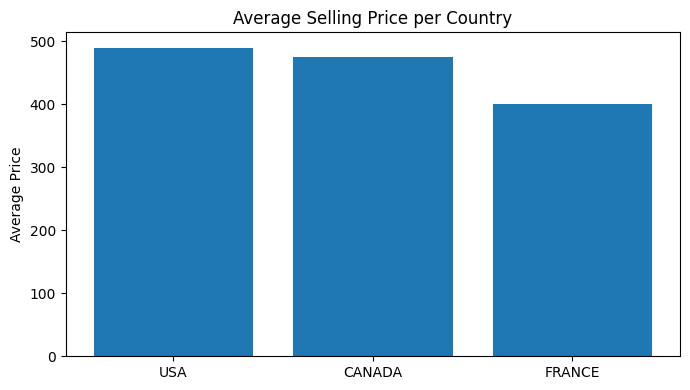

In [43]:
plt.figure(figsize=(7,4))
plt.bar(df['country'], df['avg_price'])
plt.title('Average Selling Price per Country')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

## E2. Average selling price per product

**Question:** Find average selling price per product.

### SQL

In [44]:
sql = """SELECT 
    product,
    AVG(price) AS avg_price
FROM sales
GROUP BY product
ORDER BY avg_price DESC;"""
print(sql)

SELECT 
    product,
    AVG(price) AS avg_price
FROM sales
GROUP BY product
ORDER BY avg_price DESC;


### Run SQL

In [45]:
df = con.execute(sql).df()
df

,product,avg_price
0,COMPUTER,700
1,BIKE,550
2,TV,246


### SQL Explanation
This computes the average transaction price for each product category.

### Business Insight
This helps compare premium vs lower-priced product lines and can support pricing analysis.

### Plot

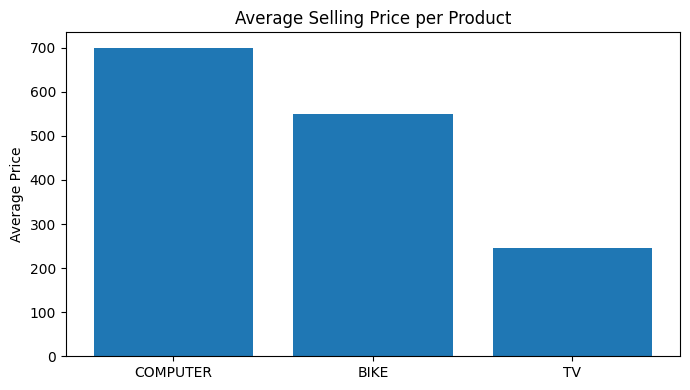

In [46]:
plt.figure(figsize=(7,4))
plt.bar(df['product'], df['avg_price'])
plt.title('Average Selling Price per Product')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

## E3. Country-product matrix with count and sales

**Question:** Find transaction count and total sales for each country-product combination.

### SQL

In [47]:
sql = """SELECT 
    country,
    product,
    COUNT(*) AS num_sales,
    SUM(price) AS total_sales
FROM sales
GROUP BY country, product
ORDER BY country, product;"""
print(sql)

SELECT 
    country,
    product,
    COUNT(*) AS num_sales,
    SUM(price) AS total_sales
FROM sales
GROUP BY country, product
ORDER BY country, product;


### Run SQL

In [48]:
df = con.execute(sql).df()
df

,country,product,num_sales,total_sales
0,CANADA,COMPUTER,2,"1,400"
1,CANADA,TV,2,500
2,FRANCE,BIKE,2,"1,000"
3,FRANCE,TV,2,600
4,USA,BIKE,2,"1,200"
5,USA,COMPUTER,3,"2,100"
6,USA,TV,3,620


### SQL Explanation
This is a richer multi-dimensional aggregation because it combines both `COUNT(*)` and `SUM(price)` for each `(country, product)` pair.

### Business Insight
This shows both revenue and transaction volume together.  
It helps distinguish frequent low-value sales from fewer high-value sales.

# Final Teaching Notes

## Key ideas reinforced
- `GROUP BY` groups rows into categories
- `SUM`, `COUNT`, `AVG`, and `MAX` summarize each group
- `HAVING` filters grouped results
- Window functions such as `RANK()` help with top-N analysis after aggregation

## Practical business takeaway
The same dataset can answer:
- market performance questions
- product performance questions
- ranking questions
- threshold questions
- premium-price questions